<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/WLSRI_dan_Kemandirian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1UtPH4FheRLAYGKscK2Y-WjyqMbOVROjUaxkjZrg7Smw/export?format=csv"

df = pd.read_csv(url)

df

#CATATAN : 1) STATUS FILE : share everyone   2) Nama file yg dipakai ID nya (tengok di kolom link https nya)

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,B,I,Terolah,Reduksi,Liar,Hidden,Leaked
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,4000,4300,300,3000,25230,28230
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,4000,4500,500,1000,12564,13564
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,4000,4700,100,500,6152,6652
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,4000,4200,200,3000,9750,12750
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,4000,4050,50,1000,5050,6050
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,4000,9000,1000,2000,14600,16600
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,4000,14000,3000,3000,17940,20940


In [ ]:
df['SPI'] = df['Terangkut'] / df['Timbulan']
df['Reduksi_Ratio'] = df['Reduksi'] / df['Timbulan']
df['Terolah_Ratio'] = df['Terolah'] / df['Timbulan']

df['Error_Margin'] = df['Timbulan'] - (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Leakage_Index'] = df['Error_Margin'] / df['Timbulan']

df['Kemandirian_Index'] = (
    df['Reduksi'] + df['Terolah']
) / df['Timbulan']

df['WLSRI'] = (
    0.4 * df['SPI'] +
    0.2 * df['Reduksi_Ratio'] +
    0.2 * df['Terolah_Ratio'] -
    0.2 * df['Leakage_Index']
)

df = df.sort_values(by='WLSRI', ascending=False)

df

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,B,I,Terolah,...,Hidden,Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,Error_Margin,Leakage_Index,WLSRI,Kategori,Kemandirian_Index
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,4000,4700,...,6152,6652,0.6,0.003493,0.164163,6652,0.232344,0.227063,Merah (Buruk),0.167656
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,4000,4200,...,9750,12750,0.5,0.005831,0.122449,12750,0.371720,0.151312,Merah (Buruk),0.128280
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,4000,4500,...,12564,13564,0.4,0.016160,0.145443,13564,0.438397,0.104641,Merah (Buruk),0.161603
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,4000,4300,...,25230,28230,0.3,0.006397,0.091684,28230,0.601919,0.019232,Merah (Buruk),0.098081
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,4000,14000,...,17940,20940,0.0,0.079072,0.369004,20940,0.551924,-0.020770,Merah (Buruk),0.448076
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,4000,4050,...,5050,6050,0.0,0.004926,0.399015,6050,0.596059,-0.038424,Merah (Buruk),0.403941
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,4000,9000,...,14600,16600,0.0,0.037594,0.338346,16600,0.624060,-0.049624,Merah (Buruk),0.375940


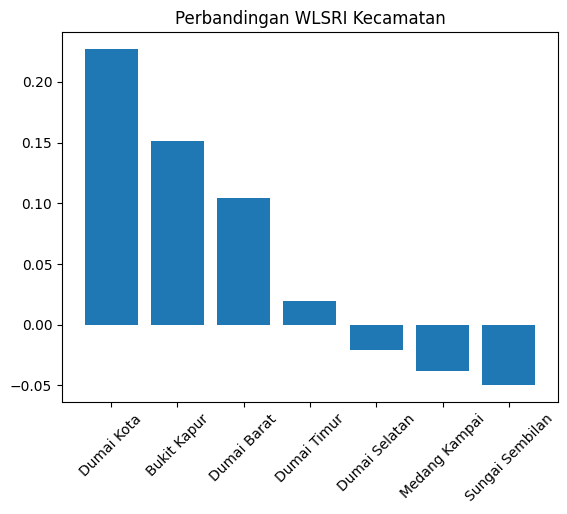

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df['Kecamatan'], df['WLSRI'])
plt.xticks(rotation=45)
plt.title("Perbandingan WLSRI Kecamatan")
plt.show()

In [ ]:
def kategori(wlsri):
    if wlsri >= 0.6:
        return "Hijau (Baik)"
    elif wlsri >= 0.3:
        return "Kuning (Sedang)"
    else:
        return "Merah (Buruk)"

df['Kategori'] = df['WLSRI'].apply(kategori)

df

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,B,I,Terolah,...,Liar,Hidden,Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,Error_Margin,Leakage_Index,WLSRI,Kategori
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,4000,4700,...,500,6152,6652,0.6,0.003493,0.164163,6652,0.232344,0.227063,Merah (Buruk)
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,4000,4200,...,3000,9750,12750,0.5,0.005831,0.122449,12750,0.371720,0.151312,Merah (Buruk)
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,4000,4500,...,1000,12564,13564,0.4,0.016160,0.145443,13564,0.438397,0.104641,Merah (Buruk)
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,4000,4300,...,3000,25230,28230,0.3,0.006397,0.091684,28230,0.601919,0.019232,Merah (Buruk)
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,4000,14000,...,3000,17940,20940,0.0,0.079072,0.369004,20940,0.551924,-0.020770,Merah (Buruk)
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,4000,4050,...,1000,5050,6050,0.0,0.004926,0.399015,6050,0.596059,-0.038424,Merah (Buruk)
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,4000,9000,...,2000,14600,16600,0.0,0.037594,0.338346,16600,0.624060,-0.049624,Merah (Buruk)


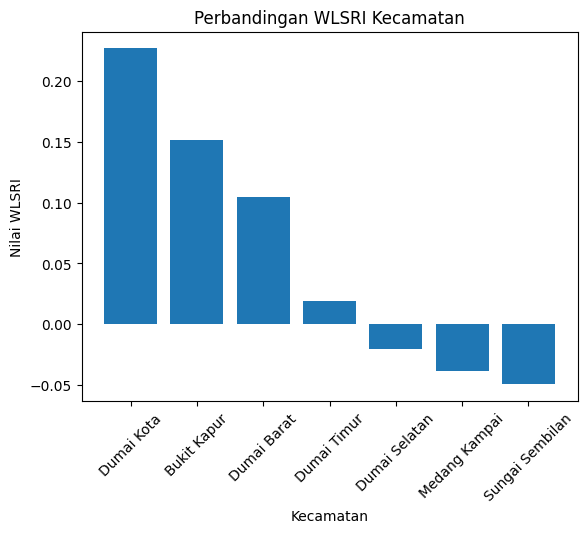

In [ ]:
plt.figure()
plt.bar(df['Kecamatan'], df['WLSRI'])
plt.xticks(rotation=45)
plt.title("Perbandingan WLSRI Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Nilai WLSRI")
plt.show()

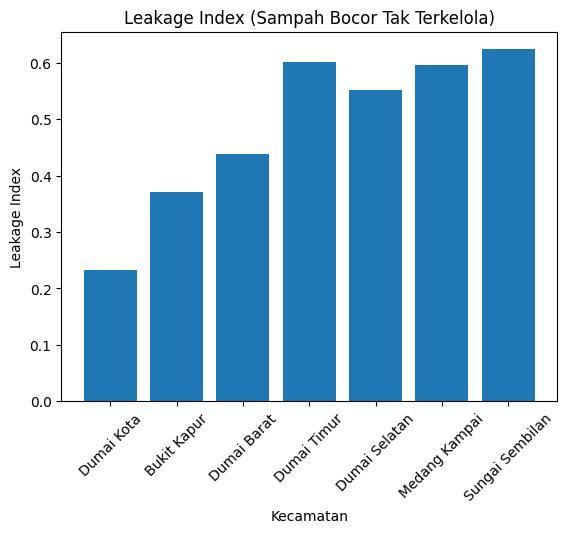

In [ ]:
plt.figure()
plt.bar(df['Kecamatan'], df['Leakage_Index'])
plt.xticks(rotation=45)
plt.title("Leakage Index (Sampah Bocor Tak Terkelola)")
plt.xlabel("Kecamatan")
plt.ylabel("Leakage Index")
plt.show()

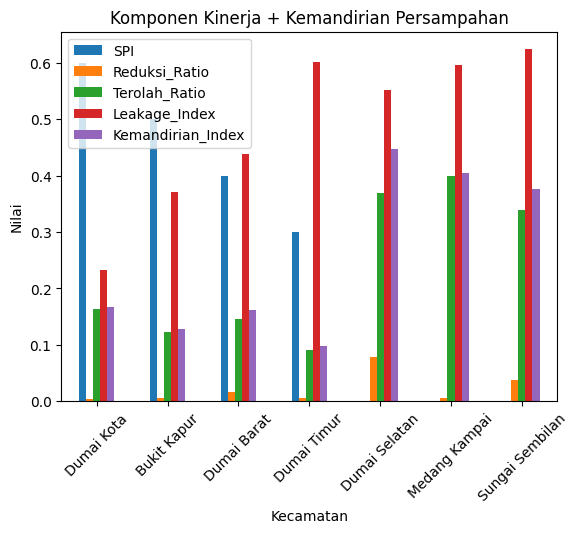

In [ ]:
df_plot = df.set_index('Kecamatan')[[
    'SPI', 'Reduksi_Ratio', 'Terolah_Ratio',
    'Leakage_Index', 'Kemandirian_Index'
]]

df_plot.plot(kind='bar')
plt.title("Komponen Kinerja + Kemandirian Persampahan")
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.show()

In [ ]:
# Validasi dasar
df['Total_Terkelola'] = (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Error_Margin'] = df['Timbulan'] - df['Total_Terkelola']

# Flag masalah
def cek_valid(row):
    if row['Error_Margin'] < 0:
        return "ERROR DATA (double counting)"
    elif row['Error_Margin'] > 0.3 * row['Timbulan']:
        return "KEBOCORAN TINGGI"
    else:
        return "OK"

df['Status_Data'] = df.apply(cek_valid, axis=1)

df[['Kecamatan','Error_Margin','Status_Data']]

,Kecamatan,Error_Margin,Status_Data
2,Dumai Kota,6652,OK
3,Bukit Kapur,12750,KEBOCORAN TINGGI
1,Dumai Barat,13564,KEBOCORAN TINGGI
0,Dumai Timur,28230,KEBOCORAN TINGGI
6,Dumai Selatan,20940,KEBOCORAN TINGGI
4,Medang Kampai,6050,KEBOCORAN TINGGI
5,Sungai Sembilan,16600,KEBOCORAN TINGGI


In [ ]:
# Ranking
df['Ranking'] = df['WLSRI'].rank(ascending=False, method='min')

# Urutkan
df = df.sort_values(by='WLSRI', ascending=False)

# Tampilkan inti perbandingan
df[['Kecamatan','WLSRI','Ranking']]

,Kecamatan,WLSRI,Ranking
2,Dumai Kota,0.227063,1.0
3,Bukit Kapur,0.151312,2.0
1,Dumai Barat,0.104641,3.0
0,Dumai Timur,0.019232,4.0
6,Dumai Selatan,-0.020770,5.0
4,Medang Kampai,-0.038424,6.0
5,Sungai Sembilan,-0.049624,7.0


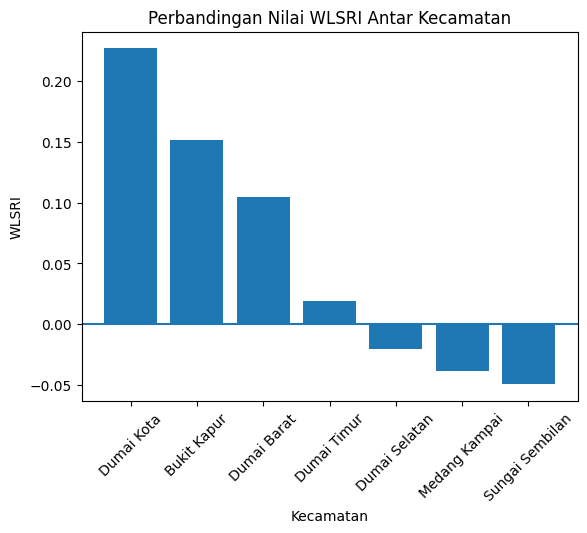

In [ ]:
plt.figure()
plt.bar(df['Kecamatan'], df['WLSRI'])
plt.xticks(rotation=45)
plt.title("Perbandingan Nilai WLSRI Antar Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("WLSRI")
plt.axhline(0)  # garis batas rata-rata
plt.show()

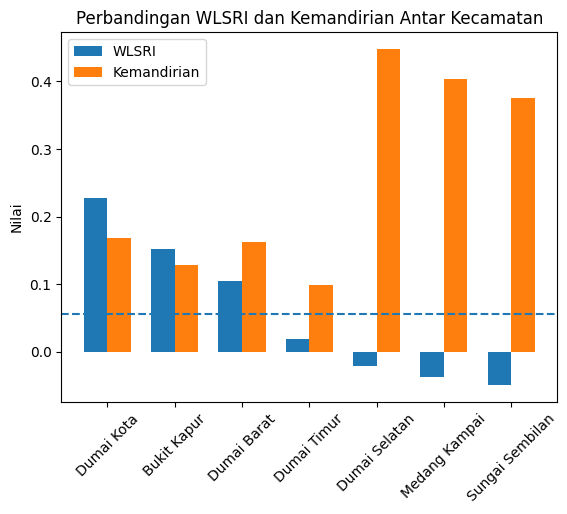

In [ ]:
import numpy as np

# pastikan sudah ada kolom ini
df['Kemandirian_Index'] = (df['Reduksi'] + df['Terolah']) / df['Timbulan']

# urutkan
df = df.sort_values(by='WLSRI', ascending=False)

x = np.arange(len(df))
width = 0.35

plt.figure()

plt.bar(x - width/2, df['WLSRI'], width, label='WLSRI')
plt.bar(x + width/2, df['Kemandirian_Index'], width, label='Kemandirian')

plt.xticks(x, df['Kecamatan'], rotation=45)
plt.ylabel("Nilai")
plt.title("Perbandingan WLSRI dan Kemandirian Antar Kecamatan")

plt.axhline(df['WLSRI'].mean(), linestyle='--')

plt.legend()
plt.show()

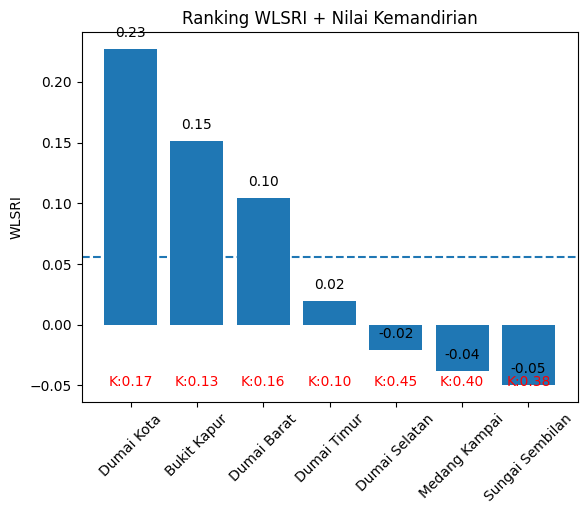

In [ ]:
plt.figure()

plt.bar(df['Kecamatan'], df['WLSRI'])

# Tambahkan nilai WLSRI di atas batang
for i, v in enumerate(df['WLSRI']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

# Tambahkan kemandirian (ditulis di bawahnya)
for i, v in enumerate(df['Kemandirian_Index']):
    plt.text(i, -0.05, f"K:{v:.2f}", ha='center', color='red')

plt.xticks(rotation=45)
plt.ylabel("WLSRI")
plt.title("Ranking WLSRI + Nilai Kemandirian")

plt.axhline(df['WLSRI'].mean(), linestyle='--')

plt.show()